# 03 - Análisis exploratorio de porcentaje de llenado de embalses

Análisis exploratorio inicial de la variable objetivo del trabajo: el porcentaje de llenado diario de los embalses del SAIH de la cuenca del Miño-Sil, para el periodo 2000-2023.

## Contenido

1. Carga del maestro de embalses (con capacidades máximas de la CHMS).
2. Carga y transformación de los datos SAIH de embalses.
3. Cálculo del porcentaje de llenado por embalse y día.
4. Visualización de series temporales, patrón estacional y distribución.

## Salida

Gráficos guardados en `outputs/figures/` para su inclusión en la memoria.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("..")
from src.saih import PATRON_COL, normalizar_id_embalse

# Rutas
DIR_RAW = Path("../data/raw")
DIR_PROCESSED = Path("../data/processed")
DIR_OUTPUTS = Path("../outputs/figures")
DIR_OUTPUTS.mkdir(parents=True, exist_ok=True)

# Configuración de estilo
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["font.size"] = 10

## 1. Cargar el maestro de embalses

In [2]:
maestro = pd.read_parquet(DIR_PROCESSED / "maestro_embalses.parquet")
print(f"Maestro de embalses cargado: {len(maestro)} embalses")
maestro.head()

Maestro de embalses cargado: 35 embalses


,ID_SAIH,Nombre_SAIH,X,Y,Sistema,Nombre_CHMS,Rio,Capacidad_hm3,Superficie_ha,Uso
0,E001,Belesar,605857.785,4720461.028,Miño Alto,BELESAR,MIÑO,645.56,1724.3111,H
1,E002,Os Peares,604739.725,4702113.693,Miño Alto,PEARES,MIÑO,182.00,482.6588,H
2,E003,As Rozas,716279.933,4753843.899,Sil Superior,ROZAS,SIL,28.00,152.9916,H
3,E05A,Matalavilla - Presa,708038.359,4745675.320,Sil Superior,MATALAVILLA,VALSECO DE,65.04,183.8903,H
4,E07A,Presa de Bárcena,700199.782,4716705.838,Sil Superior,BARCENA,SIL,341.46,953.2600,I/S/H


## 2. Cargar datos SAIH de embalses y calcular porcentaje de llenado

Los datos vienen en formato ancho (una columna por variable y embalse). Se hace UNPIVOT para obtener un formato largo con columnas fecha, ID_SAIH, variable, valor. Luego se calcula el porcentaje de llenado como Volumen SAIH / Capacidad máxima × 100.

In [3]:
# Cargar hoja de datos de embalses
df_saih = pd.read_excel(
    DIR_RAW / "saih" / "Datos_Embalses.xlsx",
    sheet_name="Datos_Embalses",
    header=[0, 1, 2],  # cabecera de 3 niveles
)

# Aplanar cabeceras multinivel
df_saih.columns = ["_".join([str(c) for c in col if pd.notna(c) and str(c) != "nan"]).strip("_")
                   for col in df_saih.columns]

# La primera columna es la fecha (aunque pueda tener nombre raro tras aplanar)
df_saih = df_saih.rename(columns={df_saih.columns[0]: "fecha"})
df_saih["fecha"] = pd.to_datetime(df_saih["fecha"], errors="coerce")

print(f"Registros: {len(df_saih)}")
print(f"Rango fechas: {df_saih['fecha'].min()} a {df_saih['fecha'].max()}")
print(f"Primeras columnas: {df_saih.columns[:5].tolist()}")

Registros: 8907
Rango fechas: 2000-01-01 00:00:00 a 2024-05-20 00:00:00
Primeras columnas: ['fecha', 'E001MACVEMBA_Volumen_(Hm3)', 'E001MAINEMBA_Nivel _(msnm)', 'E002MACVEMBA_Volumen_(Hm3)', 'E002MAINEMBA_Nivel _(msnm)']


In [4]:
VOLUMEN = ["MACVEMBA", "MAIVEMBA", "ACVEMBA"]
cols_volumen = [c for c in df_saih.columns if any(v in c for v in VOLUMEN)]
# E03S es la serie agregada del sistema Rozas-Matalavilla, no un embalse físico;
# se excluye para mantener los 35 embalses del maestro
cols_volumen = [c for c in cols_volumen if not c.startswith("E03S")]
print(f"Columnas de volumen: {len(cols_volumen)}")

# Quedarse con fecha + volúmenes
df_vol = df_saih[["fecha"] + cols_volumen].copy()

# Pasar a formato largo
df_vol_long = df_vol.melt(id_vars="fecha", var_name="col_original", value_name="volumen_hm3")

# Extraer el ID del embalse (primeros 4 caracteres antes de MACVEMBA)
df_vol_long["ID_SAIH"] = df_vol_long["col_original"].str[:4]

# Añadir la capacidad máxima desde el maestro
df_vol_long = df_vol_long.merge(
    maestro[["ID_SAIH", "Nombre_SAIH", "Capacidad_hm3"]],
    on="ID_SAIH",
    how="left"
)

# Calcular el porcentaje de llenado
df_vol_long["pct_llenado"] = (df_vol_long["volumen_hm3"] / df_vol_long["Capacidad_hm3"]) * 100

# Filtrar filas con datos válidos
df_llenado = df_vol_long.dropna(subset=["pct_llenado"]).copy()

print(f"Registros con porcentaje de llenado calculado: {len(df_llenado):,}")
print(f"Embalses cubiertos: {df_llenado['ID_SAIH'].nunique()}")
df_llenado[["fecha", "ID_SAIH", "Nombre_SAIH", "volumen_hm3", "Capacidad_hm3", "pct_llenado"]].head()

Columnas de volumen: 35
Registros con porcentaje de llenado calculado: 299,532
Embalses cubiertos: 35


,fecha,ID_SAIH,Nombre_SAIH,volumen_hm3,Capacidad_hm3,pct_llenado
0,2000-01-01,E001,Belesar,428.79,645.56,66.421402
1,2000-01-02,E001,Belesar,426.00,645.56,65.989219
2,2000-01-03,E001,Belesar,419.36,645.56,64.960654
3,2000-01-04,E001,Belesar,413.08,645.56,63.987856
4,2000-01-05,E001,Belesar,407.67,645.56,63.149823


## 3. Selección de embalses representativos

Se seleccionan tres embalses representativos por su tamaño y ubicación en la cuenca para el análisis exploratorio inicial.

- Belesar (Miño Alto, LU) – embalse principal por capacidad.
- Bárcena (Sil Superior, LE) – embalse principal del Sil.
- As Portas (Miño Bajo, OU) – embalse relevante en la cuenca sur.

In [5]:
embalses_focus = ["E001", "E07A", "E16A"]  # Belesar, Bárcena, As Portas
nombres_focus = maestro[maestro["ID_SAIH"].isin(embalses_focus)].set_index("ID_SAIH")["Nombre_SAIH"]

df_focus = df_llenado[df_llenado["ID_SAIH"].isin(embalses_focus)].copy()
print(f"Registros de los 3 embalses focus: {len(df_focus):,}")

Registros de los 3 embalses focus: 26,638


## 4. Gráfico 1: Series temporales de porcentaje de llenado (2000-2023)

Guardado: ..\outputs\figures\5_3_series_llenado_belesar_barcena_asportas.png


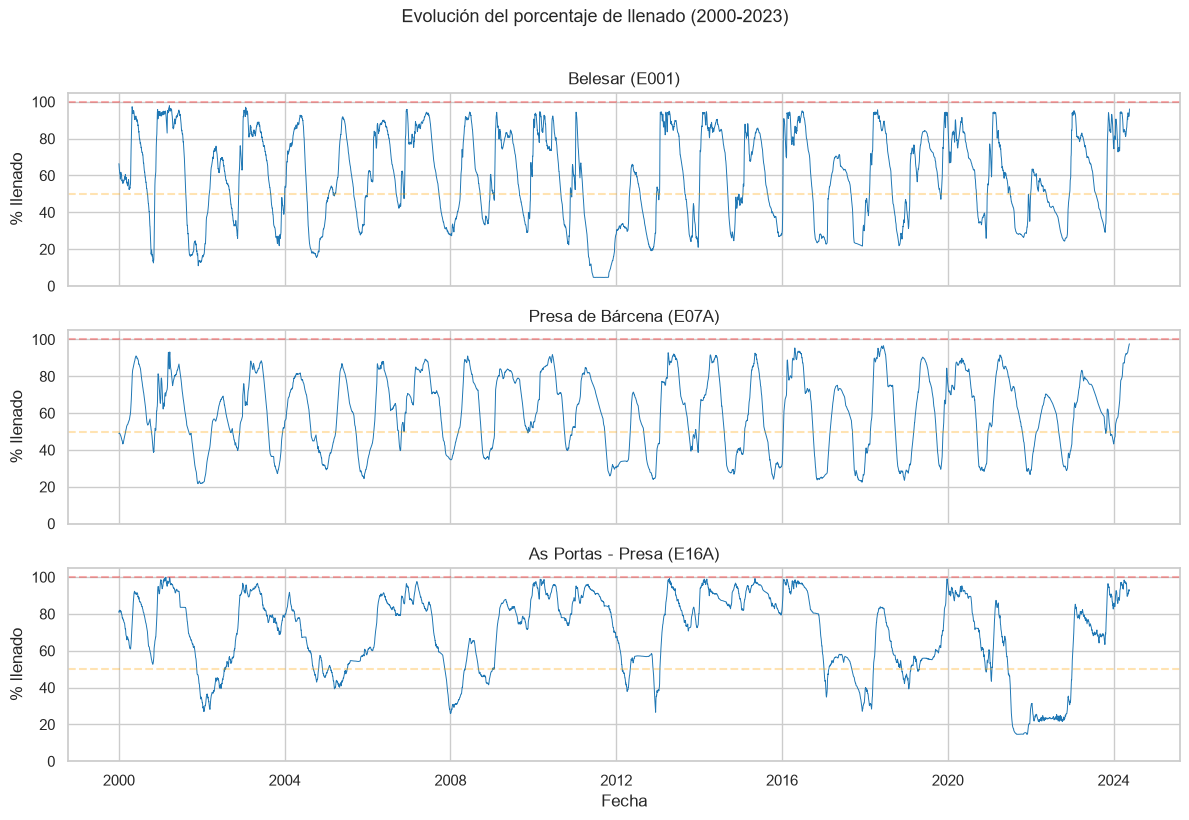

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for ax, id_emb in zip(axes, embalses_focus):
    datos = df_focus[df_focus["ID_SAIH"] == id_emb].sort_values("fecha")
    ax.plot(datos["fecha"], datos["pct_llenado"], linewidth=0.7, color="#1f77b4")
    ax.set_title(f"{nombres_focus[id_emb]} ({id_emb})")
    ax.set_ylabel("% llenado")
    ax.set_ylim(0, 105)
    ax.axhline(y=100, color="red", linestyle="--", alpha=0.3)
    ax.axhline(y=50, color="orange", linestyle="--", alpha=0.3)

axes[-1].set_xlabel("Fecha")
fig.suptitle("Evolución del porcentaje de llenado (2000-2023)", fontsize=13, y=1.02)
fig.tight_layout()

salida = DIR_OUTPUTS / "5_3_series_llenado_belesar_barcena_asportas.png"
fig.savefig(salida, bbox_inches="tight")
print(f"Guardado: {salida}")
plt.show()

## 5. Gráfico 2: Patrón estacional promedio

Guardado: ..\outputs\figures\5_3_patron_estacional_llenado.png


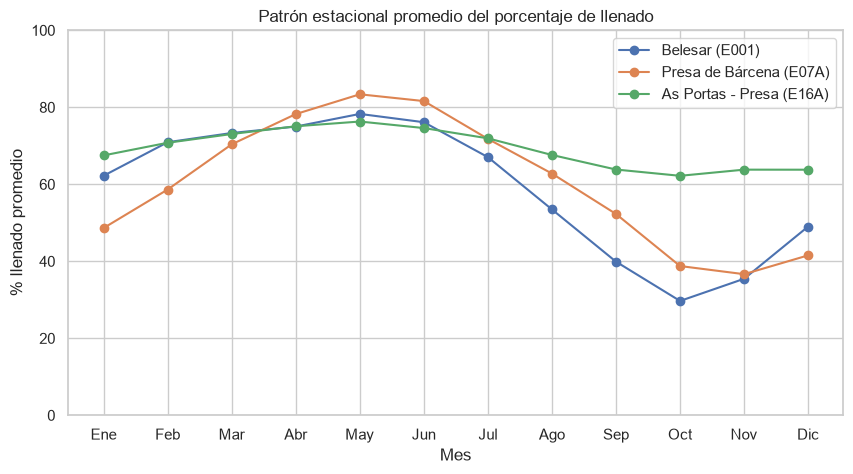

In [7]:
df_focus["mes"] = df_focus["fecha"].dt.month
patron = df_focus.groupby(["ID_SAIH", "mes"])["pct_llenado"].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
for id_emb in embalses_focus:
    datos = patron[patron["ID_SAIH"] == id_emb]
    ax.plot(datos["mes"], datos["pct_llenado"], marker="o", label=f"{nombres_focus[id_emb]} ({id_emb})")

ax.set_xlabel("Mes")
ax.set_ylabel("% llenado promedio")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"])
ax.set_title("Patrón estacional promedio del porcentaje de llenado")
ax.legend()
ax.set_ylim(0, 100)

salida = DIR_OUTPUTS / "5_3_patron_estacional_llenado.png"
fig.savefig(salida, bbox_inches="tight")
print(f"Guardado: {salida}")
plt.show()

## 6. Gráfico 3: Distribución del porcentaje de llenado por embalse

Guardado: ..\outputs\figures\5_3_distribucion_llenado_embalses.png


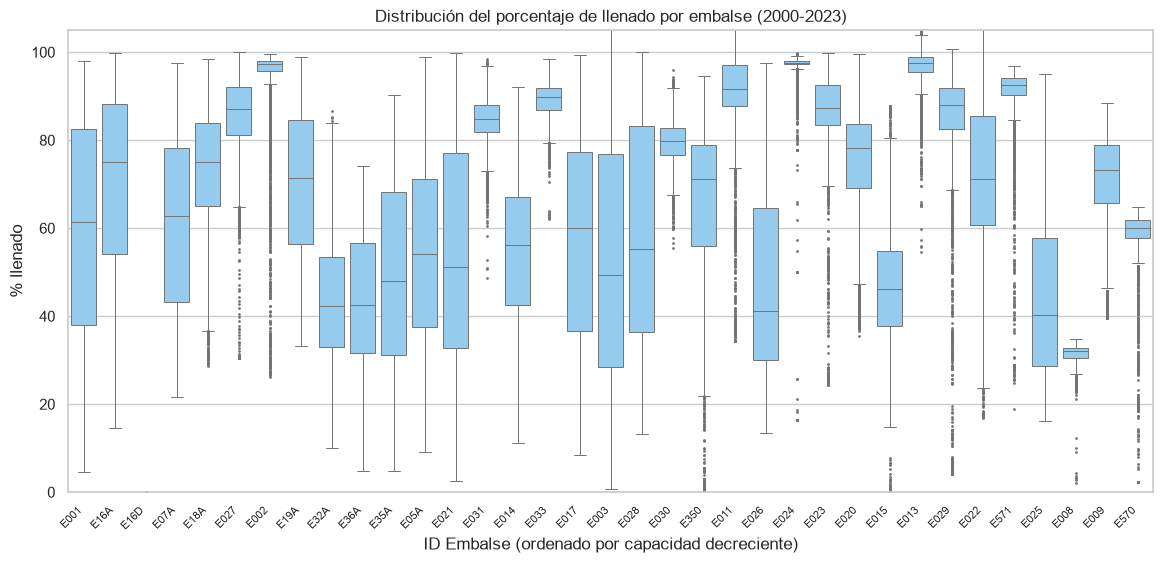

In [8]:
# Usar todos los embalses, no solo los 3 focus, para tener contexto
fig, ax = plt.subplots(figsize=(14, 6))
orden = maestro.sort_values("Capacidad_hm3", ascending=False)["ID_SAIH"].tolist()
orden = [i for i in orden if i in df_llenado["ID_SAIH"].unique()]

sns.boxplot(
    data=df_llenado,
    x="ID_SAIH",
    y="pct_llenado",
    order=orden,
    ax=ax,
    color="#87cefa",
    linewidth=0.7,
    fliersize=1,
)
ax.set_xlabel("ID Embalse (ordenado por capacidad decreciente)")
ax.set_ylabel("% llenado")
ax.set_title("Distribución del porcentaje de llenado por embalse (2000-2023)")
ax.set_ylim(0, 105)
plt.xticks(rotation=45, ha="right", fontsize=8)

salida = DIR_OUTPUTS / "5_3_distribucion_llenado_embalses.png"
fig.savefig(salida, bbox_inches="tight")
print(f"Guardado: {salida}")
plt.show()

## 7. Estadísticos por embalse

In [9]:
stats = df_llenado.groupby(["ID_SAIH", "Nombre_SAIH"]).agg(
    n_dias=("pct_llenado", "count"),
    media=("pct_llenado", "mean"),
    mediana=("pct_llenado", "median"),
    minimo=("pct_llenado", "min"),
    maximo=("pct_llenado", "max"),
).round(2).reset_index()

# Añadir capacidad para contexto
stats = stats.merge(maestro[["ID_SAIH", "Capacidad_hm3"]], on="ID_SAIH")
stats = stats.sort_values("Capacidad_hm3", ascending=False)

print(stats.to_string())

   ID_SAIH             Nombre_SAIH  n_dias  media  mediana  minimo  maximo  Capacidad_hm3
0     E001                 Belesar    8907  59.34    61.50    4.65   97.88         645.56
25    E16A       As Portas - Presa    8824  69.24    75.12   14.64   99.90         535.71
26    E16D  As Portas - C.H. Conso    8666   0.03     0.03    0.01    0.04         535.71
24    E07A        Presa de Bárcena    8907  60.48    62.87   21.70   97.63         341.46
27    E18A             Bao - Presa    8808  73.12    74.98   28.74   98.42         238.10
17    E027             San Esteban    8820  84.94    87.08   30.46  100.02         213.23
1     E002               Os Peares    8907  94.36    97.26   26.09   99.53         182.00
28    E19A           Prada - Presa    8907  70.13    71.39   33.26   98.95         122.00
29    E32A      Albarellos - Presa    8907  43.27    42.30    9.95   86.65          90.73
32    E36A           Salas - Presa    8907  43.33    42.58    4.70   74.18          86.67
31    E35A